# TO:DO 
## check: https://www.nature.com/articles/nature17995 cumulative effect of mutations

Fitness score is cholesterol accumulation.\
This is the article for this dataset: https://pubmed.ncbi.nlm.nih.gov/35190686/ \
Can I predict severity scores of real patients using the model trained on fitness scores?

## Why genomic model?

* We lose information if we use protein sequences.
* 3 **synonomous** substitutions had deleterious effect on function score
* 10 positions had different SPE Classification depending on nucleotide.

## Plan

1. Train model on HEK dataset.
2. Show model generalization across different parts of the protein
3. Show model generalization on different cell line (make sure positions are different and there is no data leakage!)
4. Use fitness score model to predict severity scores from genome??? But sounds very cool, need to think how to bridge these two! Maybe I can fine tune foundation model on dataset and then produce embeddings and then embeddigns x learnable weight for severity score.

## Bimodal distribution 
1. try first simple regression if quality is poor
2. then mixture of experts: split samples to 2 groups and then train separate regressors for each group.

## Embeddings

If you want to use all your data for embeddings eventually (e.g. for a final production model), the workflow is:

Do train/test split
Fine-tune on train, evaluate on test to get honest performance metrics
Once satisfied, retrain final model on full dataset — but you report the performance from step 2, not from the full-data model

Why I plan to use RNA and I don't want to use DNA - Length of DNA is 62119

In [13]:
import pandas as pd

# CDS is a position within coding sequence
df = pd.read_excel('data/NPC1_mut_fitness_scores.xlsx', header=1)
df.head(2)

,Protein Annotation,Wild type Base,Edited Base,CDS,Consequence,SPE Classification,Function Score,id,start,end,reference_base,alternate_base,refseq_id,Clinvar_SIG,CADD_phred,Unadjusted Function Score
0,L1027L,T,A,3081,synonymous,Functional,0.954726,chr18-23536836-23536837-A-T,23536836,23536837,A,T,NPC1:NM_000271:exon21:c.T3081A:p.L1027L:Select,NaN,NaN,0.188709
1,L1027L,T,C,3081,synonymous,Functional,0.999139,chr18-23536836-23536837-A-G,23536836,23536837,A,G,NPC1:NM_000271:exon21:c.T3081C:p.L1027L:Select,NaN,NaN,0.008803


In [18]:
set([x.split(":")[1] for x in df['refseq_id']])

{'NM_000271'}

In [14]:
df['Protein Annotation'].unique()

<StringArray>
['L1027L', 'G1028S', 'G1028R', 'G1028C', 'G1028D', 'G1028A', 'G1028V',
 'G1028G', 'H1029N', 'H1029D',
 ...
  'S918F',  'S918S',  'L919M',  'L919V',  'L919L',  'L919Q',  'L919P',
  'L919R',  'V920M',  'V920L']
Length: 770, dtype: str

In [15]:
numbers = [int(x[1:-1]) if isinstance(x,str) else x
           for x in df['Protein Annotation'].unique()]
min(numbers), max(numbers)

(347, 1190)

![alt text](image.png)

In [16]:
print(f"The size of the dataframe {df.shape}")


print(f"There are {df[df['Consequence'] == 'splice region'].shape[0]} variants in the splice region. They will be excluded from the dataset for modeling, as we will focus on coding sequence.")
df = df[~(df['Consequence'] == 'splice region')]
sample_number = df.shape[0]
df.to_csv('output/df_preprocessed.csv')
assert False

The size of the dataframe (978, 16)
There are 9 variants in the splice region. They will be excluded from the dataset for modeling, as we will focus on coding sequence.


AssertionError: 

In [ ]:
df[df['Consequence'] == "synonymous"]['SPE Classification'].value_counts()

SPE Classification
Functional     223
Uncertain        3
Deleterious      3
Name: count, dtype: int64

In [ ]:
df[(df['Consequence'] == "synonymous") & (df['SPE Classification'].isin(["Deleterious", "Uncertain"]))]

,Protein Annotation,Wild type Base,Edited Base,CDS,Consequence,SPE Classification,Function Score,id,start,end,reference_base,alternate_base,refseq_id,Clinvar_SIG,CADD_phred,Unadjusted Function Score
96,V1065V,C,A,3195,synonymous,Uncertain,0.847789,chr18-23536722-23536723-G-T,23536722,23536723,G,T,NPC1:NM_000271:exon21:c.C3195A:p.V1065V:Select,NaN,21.50,0.322781
160,A1187A,G,C,3561,synonymous,Uncertain,0.889076,chr18-23534475-23534476-C-G,23534475,23534476,C,G,NPC1:NM_000271:exon23:c.G3561C:p.A1187A:Select,NaN,NaN,0.401739
246,G1034G,A,C,3102,synonymous,Uncertain,0.953153,chr18-23536815-23536816-T-G,23536815,23536816,T,G,NPC1:NM_000271:exon21:c.A3102C:p.G1034G:Select,NaN,NaN,0.170578
527,E730E,A,G,2190,synonymous,Deleterious,0.094668,chr18-23543509-23543510-T-C,23543509,23543510,T,C,NPC1:NM_000271:exon14:c.A2190G:p.E730E:Select,NaN,10.73,4.109014
554,P733P,C,T,2199,synonymous,Deleterious,0.107730,chr18-23543500-23543501-G-A,23543500,23543501,G,A,NPC1:NM_000271:exon14:c.C2199T:p.P733P:Select,Uncertain_significance,NaN,4.056919
873,V908V,G,A,2724,synonymous,Deleterious,0.174009,chr18-23539881-23539882-C-T,23539881,23539882,C,T,NPC1:NM_000271:exon18:c.G2724A:p.V908V:Select,NaN,11.91,2.697848


In [ ]:
# Let's see if same protein substitutions have different effect on function score
position_classes = df.groupby(['Protein Annotation'])["SPE Classification"].nunique()
mixed_pos = position_classes[position_classes > 1].index

print(f"{len(mixed_pos)} positions with multiple classifications out of {len(df['CDS'].unique())} unique positions")
#df[df['Protein Annotation'].isin(mixed_pos)]

10 positions with multiple classifications out of 323 unique positions


<Axes: >

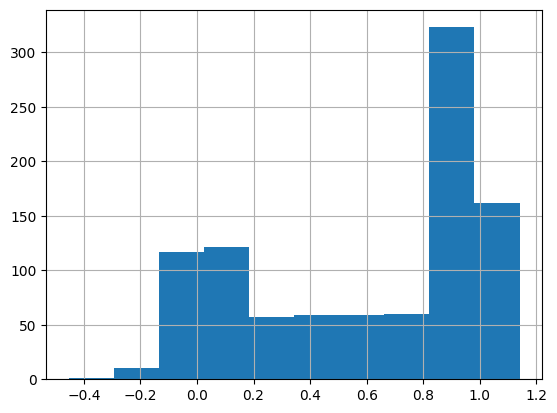

In [ ]:
df['Function Score'].hist()

In [ ]:
df['CDS'] = df['CDS'].astype(int)
df['CDS'].min(), df['CDS'].max()

(np.int64(1040), np.int64(3568))

In [ ]:
import requests
from Bio import SeqIO
from io import StringIO
import numpy as np

url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NM_000271.5&rettype=fasta&retmode=text"
response = requests.get(url)

record_RNA  = SeqIO.read(StringIO(response.text), "fasta")
seq = record_RNA.seq

cds_start = record_RNA.seq.find("ATG")
cds_pos = 3081
ind = cds_start + cds_pos - 1
print(f"Length of mRNA NPC1: {len(seq)} nucleotides")
print(f"CDS position: {cds_pos}, Genomic position: {ind}")
print(f"Reference nucleotide: {seq[ind]}")

def mutate_seq(seq, pos, new_base):
    cds_start = record_RNA.seq.find("ATG")
    ind = pos + cds_start - 1
    assert df['Wild type Base'][i] == seq[ind]
    new_seq = str(seq)
    new_seq = new_seq[:ind] + new_base + new_seq[ind+1:] 
    return new_seq

new_seqs = []

for i in (df.index):
    pos = df['CDS'][i]
    new_base = df['Edited Base'][i]
    new_seq = mutate_seq(seq, pos, new_base)
    new_seqs.append(new_seq)

new_seqs = np.array(new_seqs)
assert sample_number == new_seqs.shape[0]
np.save("output/NPC1_mut_seq.npy", new_seqs)

In [ ]:
len(df)

969

In [ ]:
df = np.load("output/NPC1_mut_seq.npy")
df.shape

(969,)

In [ ]:
df[1:5]

array(['CTTCCTGACCGGCGCGCGCAGCCTGCTGCCGCGGTCAGCGCCTGCTCCTGCTCCTCCGCTCCTCCTGCGCGGGGTGCTGAAACAGCCCGGGGAAGTAGAGCCGCCTCCGGGGAGCCCAACCAGCCGAACGCCGCCGGCGTCAGCAGCCTTGCGCGGCCACAGCATGACCGCTCGCGGCCTGGCCCTTGGCCTCCTCCTGCTGCTACTGTGTCCAGCGCAGGTGTTTTCACAGTCCTGTGTTTGGTATGGAGAGTGTGGAATTGCATATGGGGACAAGAGGTACAATTGCGAATATTCTGGCCCACCAAAACCATTGCCAAAGGATGGATATGACTTAGTGCAGGAACTCTGTCCAGGATTCTTCTTTGGCAATGTCAGTCTCTGTTGTGATGTTCGGCAGCTTCAGACACTAAAAGACAACCTGCAGCTGCCTCTACAGTTTCTGTCCAGATGTCCATCCTGTTTTTATAACCTACTGAACCTGTTTTGTGAGCTGACATGTAGCCCTCGACAGAGTCAGTTTTTGAATGTTACAGCTACTGAAGATTATGTTGATCCTGTTACAAACCAGACGAAAACAAATGTGAAAGAGTTACAATACTACGTCGGACAGAGTTTTGCCAATGCAATGTACAATGCCTGCCGGGATGTGGAGGCCCCCTCAAGTAATGACAAGGCCCTGGGACTCCTGTGTGGGAAGGACGCTGACGCCTGTAATGCCACCAACTGGATTGAATACATGTTCAATAAGGACAATGGACAGGCACCTTTTACCATCACTCCTGTGTTTTCAGATTTTCCAGTCCATGGGATGGAGCCCATGAACAATGCCACCAAAGGCTGTGACGAGTCTGTGGATGAGGTCACAGCACCATGTAGCTGCCAAGACTGCTCTATTGTCTGTGGCCCCAAGCCCCAGCCCCCACCTCCTCCTGCTCCCTGGACGATCCTTGGCTTGGACGCCATGTATGTCATCATGTGGATCACCTACA

In [ ]:
df['Function Score'].describe()

count    978.000000
mean       0.603303
std        0.404846
min       -0.453831
25%        0.171957
50%        0.820706
75%        0.959942
max        1.140770
Name: Function Score, dtype: float64

In [ ]:
# Let's download DNA not RNA

import requests
from Bio import SeqIO
from io import StringIO
import numpy as np

# NM_000271.5 is the mRNA RefSeq — use NG_007762.1 for the genomic DNA RefSeq
url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NG_007762.1&rettype=fasta&retmode=text"
response = requests.get(url)

record_DNA = SeqIO.read(StringIO(response.text), "fasta")
seq = record_DNA.seq

# On the genomic DNA record, find the first ATG to anchor the CDS
cds_start = seq.find("ATG")
cds_pos = 3081
ind = cds_start + cds_pos - 1
print(f"Length of genomic DNA NPC1: {len(seq)} nucleotides")
print(f"CDS position: {cds_pos}, Genomic position: {ind}")
print(f"Reference nucleotide: {seq[ind]}")

def mutate_seq(seq, pos, new_base):
    cds_start = seq.find("ATG")
    ind = pos + cds_start - 1
    assert df['Wild type Base'][i] == seq[ind], (
        f"Expected {df['Wild type Base'][i]} at index {ind}, got {seq[ind]}"
    )
    new_seq = str(seq)
    new_seq = new_seq[:ind] + new_base + new_seq[ind+1:]
    return new_seq

new_seqs = []

for i in df.index:
    pos = df['CDS'][i]
    new_base = df['Edited Base'][i]
    new_seq = mutate_seq(seq, pos, new_base)
    new_seqs.append(new_seq)

new_seqs = np.array(new_seqs)
assert sample_number == new_seqs.shape[0]
np.save("output/NPC1_mut_seq_DNA.npy", new_seqs)